## Importing Libraries

In [1]:
import time
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3
import pandas as pd
import os
import plotly.express as ex

## Posts Analysis

In [ ]:
db_path = os.path.join(os.getcwd(), 'posts.db')
conn = sqlite3.connect(db_path)

df_posts = pd.read_sql_query("SELECT * FROM reddit_posts WHERE timestamp > '2026-01-01'", conn)

### Filtering Posts from June 1 2026 to June 21 2026

In [ ]:
df_posts=df_posts[df_posts['timestamp'] <= pd.Timestamp('2026-06-21')]
df_posts=df_posts[df_posts['timestamp'] >= pd.Timestamp('2026-06-01')]

## Risk Level Distribution

In [ ]:
px.pie(df_posts, names='risk_level', title='Distribution of Posts by Risk Level')

## Sentiment Distribution

In [29]:
px.pie(df_posts, names='sentiment', title='Distribution of Posts by Sentiment')

## Post Trend Over Time

In [30]:
 
df_posts['timestamp'] = pd.to_datetime(df_posts['timestamp'])
df_posts_grouped = df_posts.groupby(df_posts['timestamp'].dt.date).size().reset_index(name='count')
px.line(df_posts_grouped, x='timestamp', y='count', title='Post Trend Over Time (from June 1, 2026)', labels={'timestamp': 'Date', 'count': 'Number of Posts'})


## Location Analysis

In [ ]:
df = pd.read_sql_query("SELECT * FROM locations WHERE timestamp > '2026-01-01' ", conn)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 761 entries, 0 to 760
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          761 non-null    int64  
 1   username    761 non-null    object 
 2   risk_level  761 non-null    object 
 3   timestamp   761 non-null    object 
 4   location    761 non-null    object 
 5   latitude    761 non-null    float64
 6   longitude   761 non-null    float64
dtypes: float64(2), int64(1), object(4)
memory usage: 41.7+ KB


In [ ]:
for i in range(504,df.shape[0]):
    df['post_content'][i]=df_posts[df_posts['timestamp']==df['timestamp'][i]]['content'] 

### Integrating LLM model into Locations Extracted by Spacy and Geocoding them using Nominatim

In [5]:
import os
from dotenv import load_dotenv

load_dotenv()

os.environ['GROQ_API_KEY']=os.getenv('GROQ_API_KEY')

os.environ['OPENAI_API_KEY']=os.getenv('OPENAI_API_KEY')

from langchain_openai import ChatOpenAI
llm_openai=ChatOpenAI(model='gpt-4.1-mini')
 

In [32]:
prompt = """
Extract the post author's location.

Output Rules:
- Return exactly one location.
- Prefer the most specific location that can be reasonably inferred.
- Priority order:
  1. District/County
  2. City
  3. State/Province/Region
  4. Country
- Return only the single best location with according to this priority.
- Use the location's universally recognized English name with explanded abbreviations.
- If no location can be determined, return exactly: NULL
- Do not provide explanations, reasoning, notes, labels, punctuation, or any additional text.

Post: {post_content}
"""

def extract_location(post_content, model):
    new_prompt=prompt.format(post_content=post_content)
    response=model.invoke(new_prompt).content
    return response

In [34]:
for i in range(504,df.shape[0]):
    if(i%30==0):
        print(f"Extracted location for {i} posts")
    post_content=df['post_content'][i]
    predictedlocation2=extract_location(post_content,llm_openai)
    df.at[i,'predicted_location2']=predictedlocation2.split("Location:")[-1].strip()


Extracted location for 510 posts
Extracted location for 540 posts
Extracted location for 570 posts
Extracted location for 600 posts
Extracted location for 630 posts
Extracted location for 660 posts
Extracted location for 690 posts
Extracted location for 720 posts
Extracted location for 750 posts


In [7]:
import nltk
from nltk.corpus import stopwords
import spacy
from geopy.geocoders import Nominatim
import pandas as pd

nlp=spacy.load('en_core_web_sm')
nltk.download('stopwords')
STOPWORDS= set(stopwords.words('english'))
geolocator= Nominatim(user_agent='crisis_detector')

def extract_location_spacy(text):
    if isinstance(text,str):
        doc = nlp(text)
        for ent in doc.ents:
            if ent.label_ == 'GPE' or ent.label_ == 'LOC':
                return ent.text
            
    return None        
    
def geocode_location(place):
   
    location = geolocator.geocode(place, addressdetails=True,language='en',timeout=10)
    if location:
        address = location.raw.get('address',{})
        city=address.get('city') or address.get('town') or address.get('village')
        state=address.get('state')
        country=address.get('country')
        latitude=location.latitude,
        longitude=location.longitude
        return pd.Series({'latitude':latitude,'longitude':longitude,'address':address,'city':city,'state':state,'country':country})
    
    return pd.Series({'latitude':None,'longitude':None,'address':None,'city':None,'state':None,'country':None})


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\gokul\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
for i in range(504,df.shape[0]):
    predicted_location=df['predicted_location2'][i]
    try:
        if(i%30==0):
            print(f"Geocoded location for {i} posts")
        if predicted_location and predicted_location != 'NULL':
            geocoded_info = geocode_location(predicted_location)
            time.sleep(1)
            print(geocoded_info)
            latitude, longitude, address, city, state, country = geocoded_info[['latitude', 'longitude', 'address', 'city', 'state', 'country']]
            df.at[i, 'Latitude'] = latitude
            df.at[i, 'Longitude'] = longitude
            df.at[i, 'address'] = address
            df.at[i, 'city'] = city    
            df.at[i, 'state'] = state
            df.at[i, 'country'] = country
        else:
            df.at[i, 'Latitude'] = None
            df.at[i, 'Longitude'] = None 
            df.at[i, 'address'] = None
            df.at[i, 'city'] = None
            df.at[i, 'state'] = None
            df.at[i, 'country'] = None

    except Exception as e:
        print(f"Error geocoding location for post {i}: {e} {predicted_location}")
        df.at[i, 'Latitude'] = None
        df.at[i, 'Longitude'] = None 
        df.at[i, 'address'] = None
        df.at[i, 'city'] = None
        df.at[i, 'state'] = None
        df.at[i, 'country'] = None

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 761 entries, 0 to 760
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   username             761 non-null    object 
 1   timestamp            761 non-null    object 
 2   post_content         761 non-null    object 
 3   predicted_location1  504 non-null    object 
 4   predicted_location2  348 non-null    object 
 5   Latitude             325 non-null    float64
 6   Longitude            325 non-null    float64
 7   address              325 non-null    object 
 8   city                 58 non-null     object 
 9   state                121 non-null    object 
 10  country              324 non-null    object 
dtypes: float64(2), object(9)
memory usage: 65.5+ KB


## Location Analysis Across Country Level, State Level and City Level

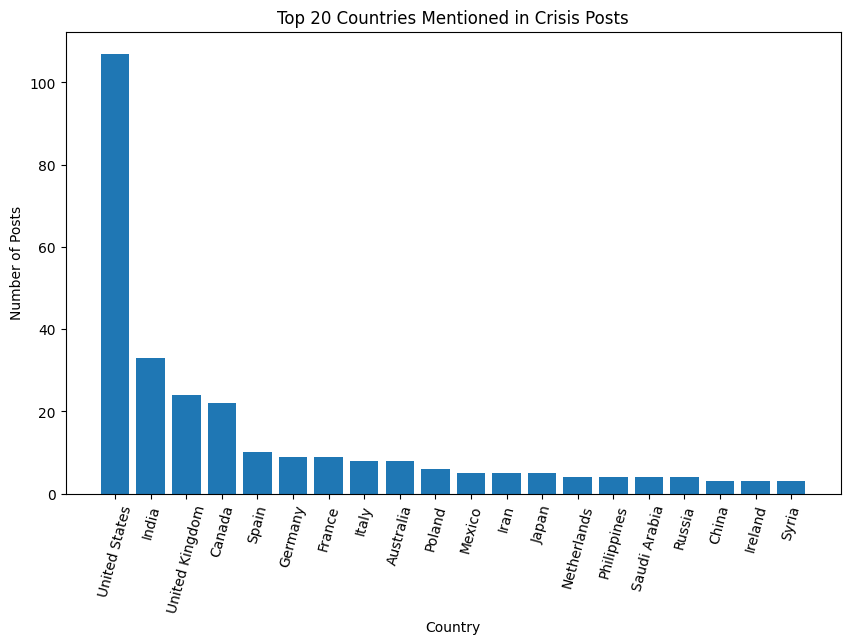

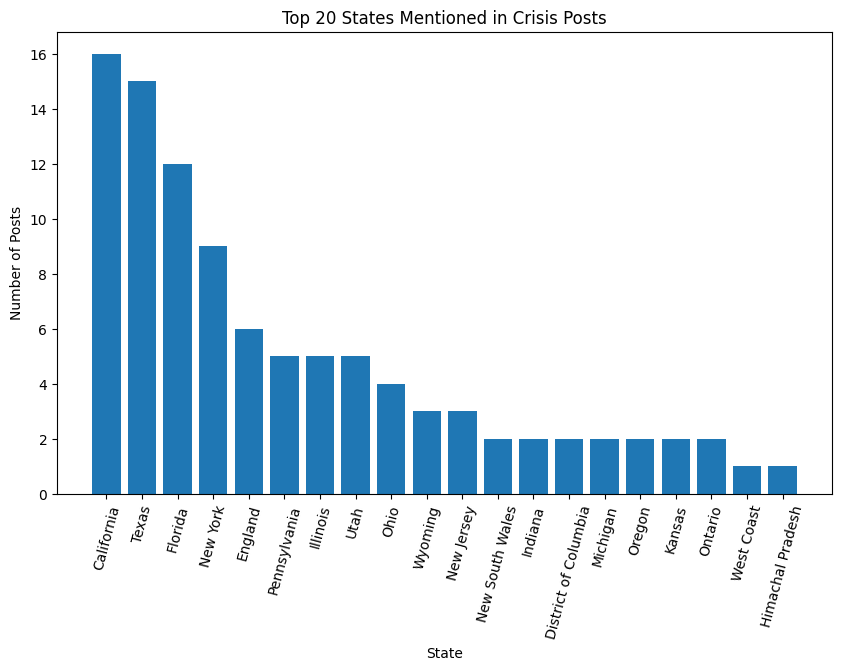

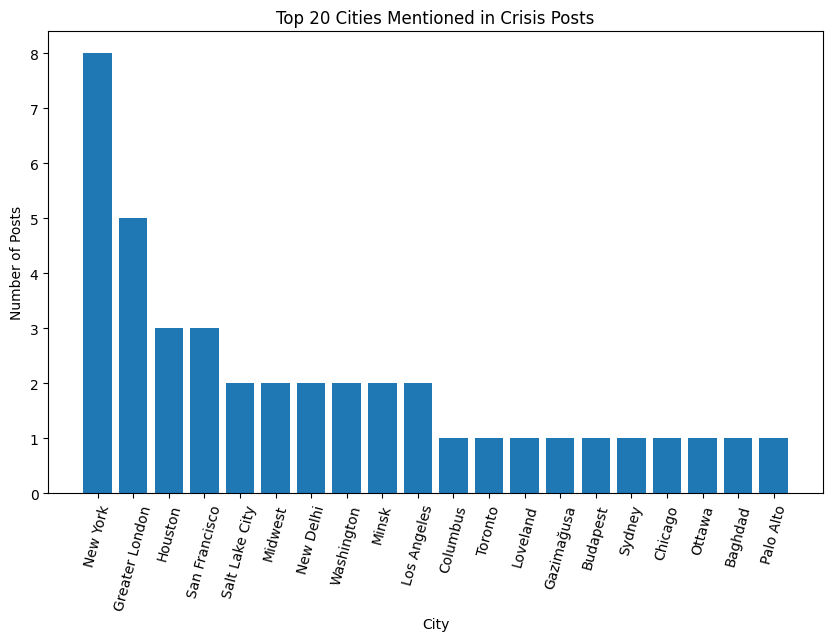

In [39]:
plt.figure(figsize=(10,6))
plt.bar(df['country'].value_counts().head(20).index, df['country'].value_counts().head(20).values)
plt.xticks(rotation=75)
plt.title('Top 20 Countries Mentioned in Crisis Posts')
plt.xlabel('Country')   
plt.ylabel('Number of Posts')
plt.show()

plt.figure(figsize=(10,6))
plt.bar(df['state'].value_counts().head(20).index, df['state'].value_counts().head(20).values)
plt.xticks(rotation=75)
plt.title('Top 20 States Mentioned in Crisis Posts')
plt.xlabel('State')
plt.ylabel('Number of Posts')
plt.show()

plt.figure(figsize=(10,6))
plt.bar(df['city'].value_counts().head(20).index, df['city'].value_counts().head(20).values)
plt.xticks(rotation=75)
plt.title('Top 20 Cities Mentioned in Crisis Posts')
plt.xlabel('City')
plt.ylabel('Number of Posts')
plt.show()


## Analyzing Locations from USA

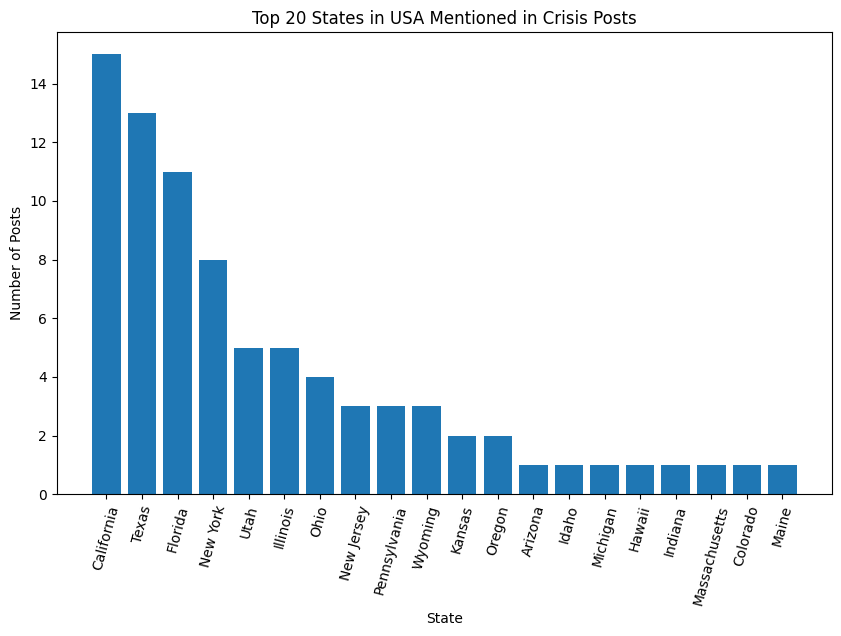

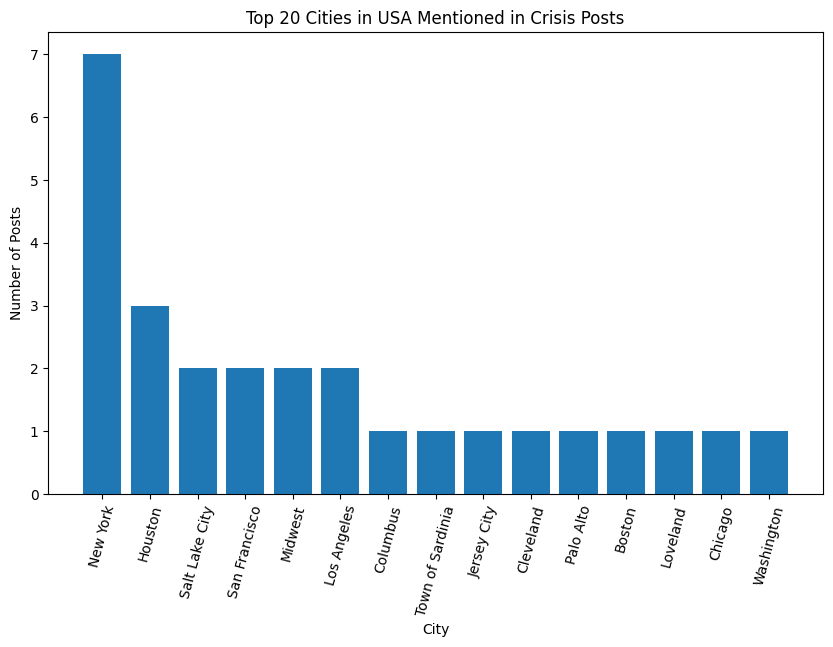

In [8]:
df_USA=df[df['country']=='United States']
plt.figure(figsize=(10,6))
plt.bar(df_USA['state'].value_counts().head(20).index , df_USA['state'].value_counts().head(20).values)
plt.xticks(rotation=75) 
plt.title('Top 20 States in USA Mentioned in Crisis Posts')
plt.xlabel('State')
plt.ylabel('Number of Posts')
plt.show()

plt.figure(figsize=(10,6))
plt.bar(df_USA['city'].value_counts().head(20).index , df_USA['city'].value_counts().head(20).values)
plt.xticks(rotation=75)
plt.title('Top 20 Cities in USA Mentioned in Crisis Posts')
plt.xlabel('City')
plt.ylabel('Number of Posts')
plt.show()

## Generating the HeatMap

In [ ]:
import folium
from folium.plugins import HeatMap

heatmap_data = df[['Latitude', 'Longitude']].dropna().values.tolist()
heatmap_map = folium.Map(location=[df['Latitude'].mean(), df['Longitude'].mean()], zoom_start=3)
HeatMap(heatmap_data).add_to(heatmap_map)
heatmap_map.save('crisis_locations_heatmap.html')